In [ ]:
# import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [15]:
# load and combine data sets
def lacf(folder_path):
    all_data = []

    # Loop through files in folder and load only CSV files
    for filename in os.listdir(folder_path):
        if filename.endswith('.csv'):
            file_pth = os.path.join(folder_path, filename)
            df = pd.read_csv(file_pth, skiprows=2)
            all_data.append(df)

    # Combine all dataframes into one
    return pd.concat(all_data, ignore_index=True)

file_paths = './all_solar_data/'

# Call function and get combined data
combined_data = lacf(file_paths)


In [16]:
print("Combined Data Shape:", combined_data.shape)

Combined Data Shape: (131496, 21)


In [17]:
combined_data['datetime'] = pd.to_datetime(combined_data[['Year', 'Month', 'Day', 'Hour', 'Minute']])


In [18]:
combined_data = combined_data[combined_data['Fill Flag'] == 0].copy()


In [19]:
missing_values = combined_data.isnull().sum()
print("Missing Values in Each Column:\n", missing_values)

Missing Values in Each Column:
 Year                  0
Month                 0
Day                   0
Hour                  0
Minute                0
DHI                   0
DNI                   0
GHI                   0
Clearsky DHI          0
Clearsky DNI          0
Clearsky GHI          0
Dew Point             0
Temperature           0
Pressure              0
Relative Humidity     0
Solar Zenith Angle    0
Precipitable Water    0
Snow Depth            0
Wind Direction        0
Wind Speed            0
Fill Flag             0
datetime              0
dtype: int64


In [21]:
# feature engeneering
combined_data['Hour'] = combined_data['datetime'].dt.hour
combined_data['Month'] = combined_data['datetime'].dt.month
combined_data['DayOfYear'] = combined_data['datetime'].dt.dayofyear

# create categorical time features
combined_data['Is_morning'] = combined_data['Hour'].apply(lambda x: 1 if 6 <= x < 12 else 0)
combined_data['Is_afternoon'] = combined_data['Hour'].apply(lambda x: 1 if 12 <= x < 18 else 0)

#seasonal features
combined_data['is_summer'] = combined_data['Month'].apply(lambda x: 1 if x in [6, 7, 8] else 0)
combined_data['is_winter'] = combined_data['Month'].apply(lambda x: 1 if x in [12, 1, 2] else 0)

# Weather interaction features
combined_data['temp_humidity_interaction'] = combined_data['Temperature'] * combined_data['Relative Humidity']
combined_data['temp_difference'] = combined_data['Temperature'] - combined_data['Dew Point']

# Solar position features
combined_data['cos_zenith_angle'] = np.cos(np.radians(combined_data['Solar Zenith Angle']))     
# Lagged features (previous hour values)
combined_data['GHI_prev_hour'] = combined_data['GHI'].shift(1)
combined_data['GHI_prev_3hours'] = combined_data['GHI'].shift(3)

# Rolling average features
combined_data['GHI_rolling_mean_6h'] = combined_data['GHI'].rolling(window=6, min_periods=1).mean()

# Remove rows with NaN values created by shift operations
combined_data = combined_data.dropna()

In [22]:
#prepare data for modeling
feature_columns = [
    'Hour', 'Month', 'DayOfYear', 'Is_morning', 'Is_afternoon',
    'is_summer', 'is_winter', 'Temperature', 'Dew Point', 
    'Relative Humidity', 'Pressure', 'Wind Speed', 'Wind Direction',
    'Solar Zenith Angle', 'cos_zenith_angle', 'Precipitable Water',
    'Clearsky GHI', 'Clearsky DHI', 'Clearsky DNI',
    'temp_humidity_interaction', 'temp_difference',
    'GHI_prev_hour', 'GHI_prev_3hours', 'GHI_rolling_mean_6h'
]
# separate features and target variable
X = combined_data[feature_columns]
y = combined_data['GHI']

# split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,shuffle=False, random_state=42)

# standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
# train models - Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# predicit
lr_train_preds = lr_model.predict(X_train_scaled)
lr_test_preds = lr_model.predict(X_test_scaled)


In [24]:
#evaluate model performance
lr_train_rmse = np.sqrt(mean_squared_error(y_train, lr_train_preds))
lr_test_rmse = np.sqrt(mean_squared_error(y_test, lr_test_preds))

lr_train_r2 = r2_score(y_train, lr_train_preds)
lr_test_r2 = r2_score(y_test, lr_test_preds)

results = pd.DataFrame({
    'Model': ['Linear Regression'],
    'Train RMSE': [lr_train_rmse],
    'Test RMSE': [lr_test_rmse],
    'Train R2': [lr_train_r2],
    'Test R2': [lr_test_r2]
})
print(results)


               Model  Train RMSE  Test RMSE  Train R2   Test R2
0  Linear Regression   71.065584  63.180805  0.940394  0.954912


In [25]:
#Model 2 - Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100,max_depth=15,  random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
# predictions
rf_train_preds = rf_model.predict(X_train_scaled)
rf_test_preds = rf_model.predict(X_test_scaled)
#evaluate model performance
rf_train_rmse = np.sqrt(mean_squared_error(y_train, rf_train_preds))
rf_test_rmse = np.sqrt(mean_squared_error(y_test, rf_test_preds))
rf_train_r2 = r2_score(y_train, rf_train_preds)
rf_test_r2 = r2_score(y_test, rf_test_preds)
results = pd.DataFrame([{
    'Model': 'Random Forest Regressor',
    'Train RMSE': rf_train_rmse,
    'Test RMSE': rf_test_rmse,
    'Train R2': rf_train_r2,
    'Test R2': rf_test_r2
}])
print(results)

                     Model  Train RMSE  Test RMSE  Train R2   Test R2
0  Random Forest Regressor   28.479052   44.72214  0.990427  0.977409


In [29]:
#Gradient Boosting Regressor
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=7, random_state=42)
gb_model.fit(X_train_scaled, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,7
,min_impurity_decrease,0.0
,init,None


In [30]:
#predictions
gb_train_preds = gb_model.predict(X_train_scaled)
gb_test_preds = gb_model.predict(X_test_scaled)
#evaluate model performance
gb_train_rmse = np.sqrt(mean_squared_error(y_train, gb_train_preds))
gb_test_rmse = np.sqrt(mean_squared_error(y_test, gb_test_preds))
gb_train_r2 = r2_score(y_train, gb_train_preds)
gb_test_r2 = r2_score(y_test, gb_test_preds)
results = pd.DataFrame([{
    'Model': 'Gradient Boosting Regressor',
    'Train RMSE': gb_train_rmse,
    'Test RMSE': gb_test_rmse,
    'Train R2': gb_train_r2,
    'Test R2': gb_test_r2
}])
print(results)

                         Model  Train RMSE  Test RMSE  Train R2   Test R2
0  Gradient Boosting Regressor   39.291535   43.50232  0.981779  0.978625


In [31]:
#find the best model
model_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regressor', 'Gradient Boosting Regressor'],
    'Train RMSE': [lr_train_rmse, rf_train_rmse, gb_train_rmse],
    'Test RMSE': [lr_test_rmse, rf_test_rmse, gb_test_rmse],
    'Train R2': [lr_train_r2, rf_train_r2, gb_train_r2],
    'Test R2': [lr_test_r2, rf_test_r2, gb_test_r2]
})
print(model_results)


                         Model  Train RMSE  Test RMSE  Train R2   Test R2
0            Linear Regression   71.065584  63.180805  0.940394  0.954912
1      Random Forest Regressor   28.479052  44.722140  0.990427  0.977409
2  Gradient Boosting Regressor   39.291535  43.502320  0.981779  0.978625


In [32]:
# Identify the best model based on Test RMSE and Test R2
best_model = model_results.loc[model_results['Test RMSE'].idxmin()]  # Model with the lowest Test RMSE
best_model_based_on_r2 = model_results.loc[model_results['Test R2'].idxmax()]  # Model with the highest Test R2

print("\nBest Model based on Test RMSE:")
print(best_model)
print("\nBest Model based on Test R2:")
print(best_model_based_on_r2)


Best Model based on Test RMSE:
Model         Gradient Boosting Regressor
Train RMSE                      39.291535
Test RMSE                        43.50232
Train R2                         0.981779
Test R2                          0.978625
Name: 2, dtype: object

Best Model based on Test R2:
Model         Gradient Boosting Regressor
Train RMSE                      39.291535
Test RMSE                        43.50232
Train R2                         0.981779
Test R2                          0.978625
Name: 2, dtype: object


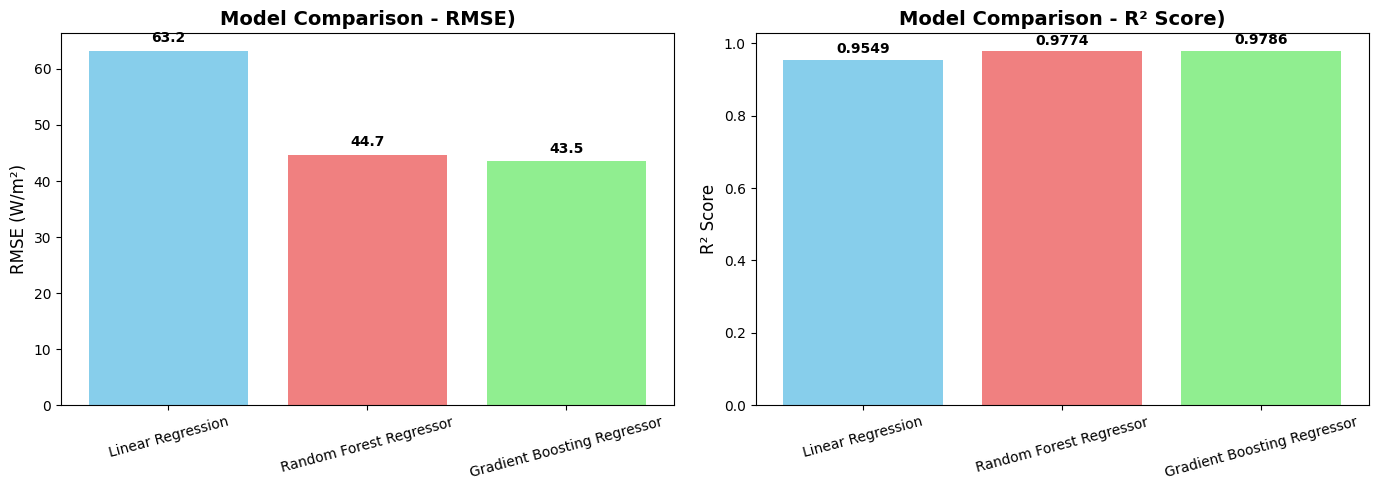

In [36]:
# Extract the models, Test RMSE, and Test R² values
models = model_results['Model']
test_rmse_values = model_results['Test RMSE']
test_r2_values = model_results['Test R2']

# Create subplots for RMSE and R² comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE comparison bar plot
axes[0].bar(models, test_rmse_values, color=['skyblue', 'lightcoral', 'lightgreen'])
axes[0].set_ylabel('RMSE (W/m²)', fontsize=12)
axes[0].set_title('Model Comparison - RMSE)', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(test_rmse_values):
    axes[0].text(i, v + 1, f'{v:.1f}', ha='center', va='bottom', fontweight='bold')  # Text placement adjusted

# R² comparison bar plot
axes[1].bar(models, test_r2_values, color=['skyblue', 'lightcoral', 'lightgreen'])
axes[1].set_ylabel('R² Score', fontsize=12)
axes[1].set_title('Model Comparison - R² Score)', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(test_r2_values):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')  # Adjust text position

# display the plots
plt.tight_layout()
plt.show()

  Creating prediction plots...


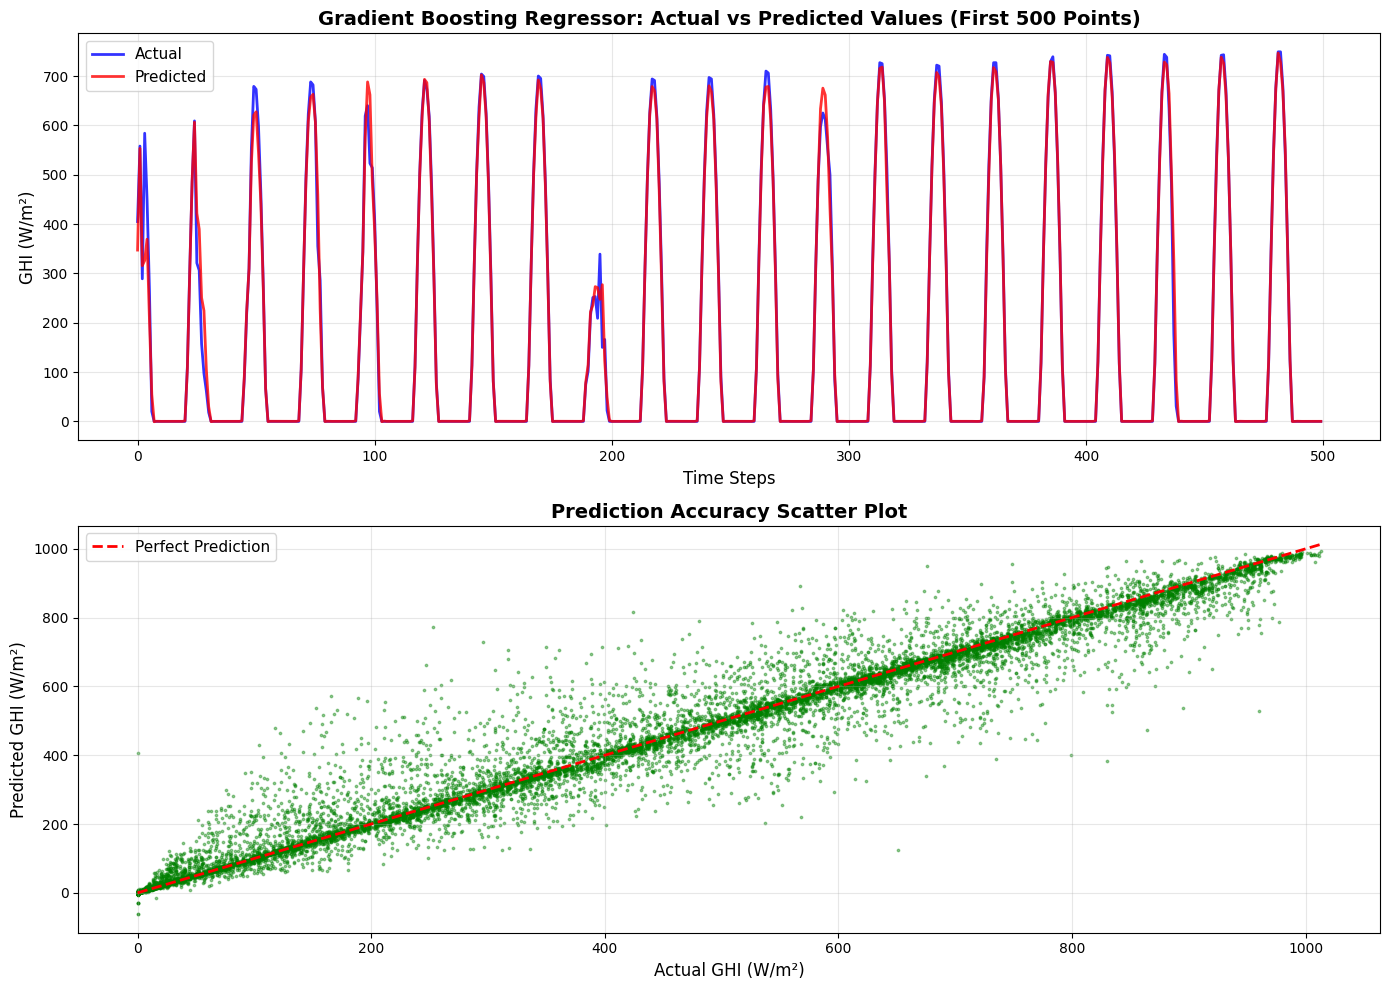

In [39]:
# VISUALIZATION 2: Predictions vs Actual
print("  Creating prediction plots...")
best_predictions = gb_model.predict(X_test_scaled)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Time series plot (first 500 points)
n_samples = 500
axes[0].plot(y_test.values[:n_samples], label='Actual', linewidth=2, alpha=0.8, color='blue')
axes[0].plot(best_predictions[:n_samples], label='Predicted', linewidth=2, alpha=0.8, color='red')
axes[0].set_xlabel('Time Steps', fontsize=12)
axes[0].set_ylabel('GHI (W/m²)', fontsize=12)
axes[0].set_title('Gradient Boosting Regressor: Actual vs Predicted Values (First 500 Points)', 
                  fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Scatter plot
axes[1].scatter(y_test, best_predictions, alpha=0.4, s=3, color='green')
axes[1].plot([y_test.min(), y_test.max()], 
             [y_test.min(), y_test.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual GHI (W/m²)', fontsize=12)
axes[1].set_ylabel('Predicted GHI (W/m²)', fontsize=12)
axes[1].set_title('Prediction Accuracy Scatter Plot', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


  Creating feature importance chart...


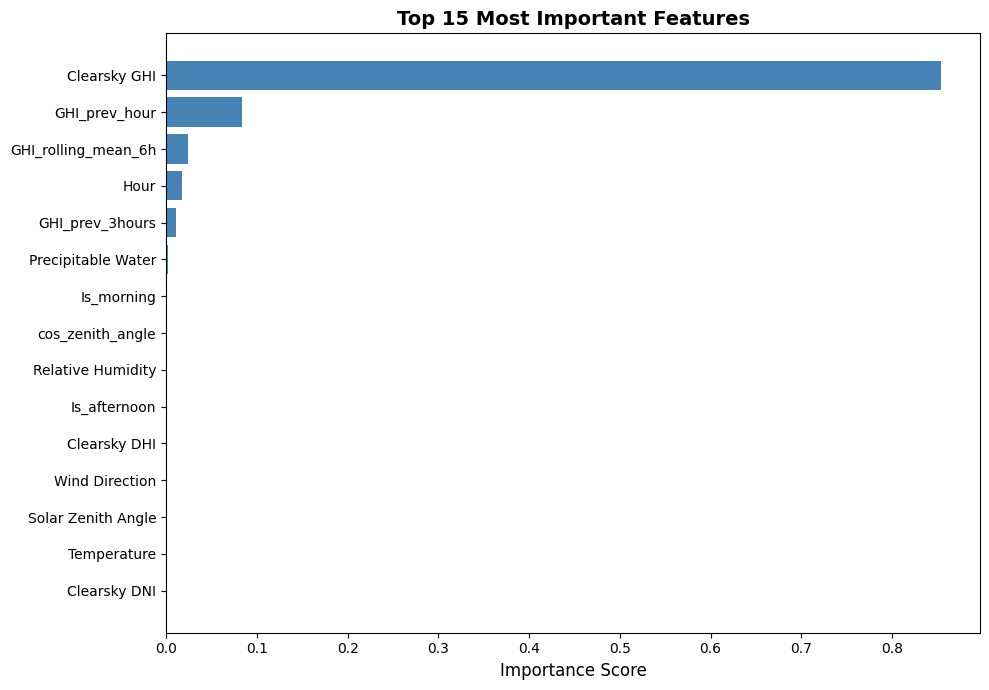

In [40]:
# VISUALIZATION 3: Feature Importance
if hasattr(gb_model, 'feature_importances_'):
    print("  Creating feature importance chart...")
    
    importances = gb_model.feature_importances_
    indices = np.argsort(importances)[::-1][:15]  # Top 15 features
    
    plt.figure(figsize=(10, 7))
    plt.title('Top 15 Most Important Features', fontsize=14, fontweight='bold')
    plt.barh(range(15), importances[indices], color='steelblue')
    plt.yticks(range(15), [feature_columns[i] for i in indices], fontsize=10)
    plt.xlabel('Importance Score', fontsize=12)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
